# Game 7 - The Black-Box Torch

**Team:** Ded_Sec

Image explanations use Grad-CAM. Text explanations use token occlusion. The
galleries are interpreted through structured case and trust tables.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path.cwd()
cases = pd.read_csv(OUTPUT_DIR / "explainability_case_analysis.csv")
trust = pd.read_csv(OUTPUT_DIR / "model_trust_assessment.csv")

display(cases)
display(trust)
print("Image gallery files:", len(list((OUTPUT_DIR / "image_explainability_gallery").glob("*.png"))))
print("Text gallery files:", len(list((OUTPUT_DIR / "text_explainability_gallery").glob("*.html"))))


,case_id,sample_id,modality,true_label,predicted_label,confidence,case_type,observed_evidence,interpretation
0,IMG_001,train__005181,image,real,fake,0.988694,high_confidence_error,center/content-heavy activation; center_mean=0...,High-confidence error with concentrated eviden...
1,IMG_002,train__006743,image,real,fake,0.987801,high_confidence_error,center/content-heavy activation; center_mean=0...,High-confidence error with concentrated eviden...
2,IMG_003,train__006797,image,real,fake,0.987620,high_confidence_error,center/content-heavy activation; center_mean=0...,High-confidence error with concentrated eviden...
3,IMG_004,train__007921,image,real,fake,0.987428,high_confidence_error,center/content-heavy activation; center_mean=0...,High-confidence error with concentrated eviden...
4,IMG_005,train__007671,image,real,fake,0.799633,incorrect,center/content-heavy activation; center_mean=0...,Incorrect prediction; the highlighted region s...
5,IMG_006,validation__001681,image,real,fake,0.799005,incorrect,center/content-heavy activation; center_mean=0...,Incorrect prediction; the highlighted region s...
6,IMG_007,train__001970,image,fake,real,0.794801,incorrect,center/content-heavy activation; center_mean=0...,Incorrect prediction; the highlighted region s...
7,IMG_008,train__002586,image,fake,real,0.793875,incorrect,border-heavy activation; center_mean=0.106; bo...,Incorrect prediction; the highlighted region s...
8,IMG_009,train__002575,image,fake,fake,0.500449,uncertain,center/content-heavy activation; center_mean=0...,Uncertain activation pattern; fusion should se...
9,IMG_010,train__002055,image,fake,fake,0.501582,uncertain,border-heavy activation; center_mean=0.064; bo...,Uncertain activation pattern; fusion should se...


,modality,observed_pattern,evidence_count,risk_level,impact_on_trust,recommended_action_for_fusion
0,image,High-confidence errors,122,high,Image confidence alone is not sufficient.,Cap image dominance on disagreement and route ...
1,image,Uncertain predictions,86,medium,Weak visual evidence needs corroboration.,Increase text/relation weight when image confi...
2,image,Border-heavy Grad-CAM focus in gallery,2,medium,"May indicate quality, padding, or framing shor...",Downweight image evidence when quality flags a...
3,text,High-confidence errors,111,high,Lexical confidence can reflect topic shortcuts.,Require image or relation agreement before tru...
4,text,Uncertain predictions,238,medium,Diffuse token evidence weakens text reliability.,Increase image/relation weight or flag for rev...
5,fusion,Image-text prediction disagreement,745,high,Image alone correct=498; text alone correct=24...,Learn reliability-aware fusion and expose disa...


Image gallery files: 16
Text gallery files: 16


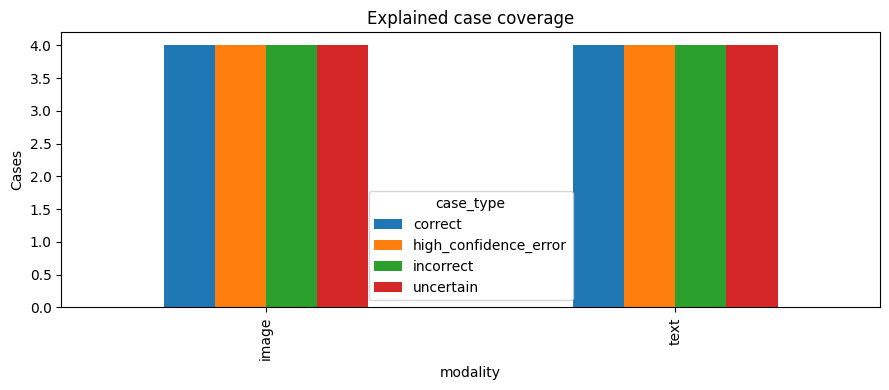

patterns
modality risk_level          
fusion   high               1
image    high               1
         medium             2
text     high               1
         medium             1

In [2]:
cases.groupby(["modality", "case_type"]).size().unstack(fill_value=0).plot.bar(
    figsize=(9, 4), title="Explained case coverage"
)
plt.ylabel("Cases")
plt.tight_layout()
plt.show()

display(
    trust.groupby(["modality", "risk_level"])
    .size()
    .to_frame("patterns")
)


## Final Conclusion

Explained 32 selected cases. Across the full validation set, image high-confidence errors=122, text high-confidence errors=111, image uncertain=86, and text uncertain=238. The models disagreed on 745 samples; image was uniquely correct on 498 and text was uniquely correct on 247. Game 8 should therefore use confidence- and quality-aware fusion, explicitly model disagreement, and flag strong cross-modal conflicts for review.
